In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

In [2]:
df = pd.read_parquet("../../data/processed/btc_features_1m.parquet")

In [3]:
df = df.dropna()

In [4]:
df.head()

,timestamp,price_measurement_timestamp,ctx_recorded_at_ms,spot_price,perp_price,spot_microprice,perp_microprice,basis_dollar,basis_bps,midprice_basis,...,microprice_3x_basis,funding_rate,open_interest,oracle_price,mark_price,ctx_mid_price,premium,impact_bid_price,impact_ask_price,day_notional_volume
0,2026-04-02 14:49:00+00:00,1775141399981,1775141399359,66751.5,66707.5,66751.013923,66707.803146,-44.000000,-6.591612,-44.000000,...,-43.238941,-0.000010,28482.68438,66750.0,66707.0,66707.5,-0.000629,66707.0,66708.0,2.950413e+09
1,2026-04-02 14:50:00+00:00,1775141459895,1775141459369,66708.5,66662.5,66708.502217,66662.984935,-46.020756,-6.898784,-46.020756,...,-45.583492,-0.000010,28559.77116,66748.0,66703.0,66662.5,-0.001178,66662.0,66669.4,2.920453e+09
2,2026-04-02 14:51:00+00:00,1775141519984,1775141519503,66761.5,66728.5,66761.802953,66728.010363,-32.999998,-4.942968,-32.999998,...,-33.786377,-0.000010,28598.21724,66768.0,66729.0,66728.5,-0.000584,66723.7,66729.0,2.923138e+09
3,2026-04-02 14:52:00+00:00,1775141579949,1775141579541,66836.0,66797.5,66833.326326,66797.999680,-39.592831,-5.923878,-39.592831,...,-37.935081,-0.000010,28602.47238,66831.0,66797.0,66791.5,-0.000569,66790.0,66793.0,2.926619e+09
4,2026-04-02 14:53:00+00:00,1775141639971,1775141639457,66818.5,66786.5,66818.775533,66786.577984,-32.091549,-4.802794,-32.091549,...,-32.422627,-0.000011,28623.98630,66829.0,66784.0,66786.5,-0.000628,66786.0,66787.0,2.928481e+09


In [5]:
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values("timestamp").reset_index(drop=True)

In [6]:
df.size

125055

In [7]:
print("rows:", len(df))
print("start:", df["timestamp"].min())
print("end:  ", df["timestamp"].max())
print("minutes covered:", (df["timestamp"].max() - df["timestamp"].min()) / pd.Timedelta(minutes=1))
print("days covered:", (df["timestamp"].max() - df["timestamp"].min()) / pd.Timedelta(days=1))

rows: 5955
start: 2026-04-02 14:49:00+00:00
end:   2026-04-06 18:05:00+00:00
minutes covered: 5956.0
days covered: 4.136111111111111


In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
price_measurement_timestamp,5955.0,1.775320e+12,1.032026e+08,1.775141e+12,1.775231e+12,1.775320e+12,1.775409e+12,1.775499e+12
ctx_recorded_at_ms,5955.0,1.775320e+12,1.032026e+08,1.775141e+12,1.775231e+12,1.775320e+12,1.775409e+12,1.775499e+12
spot_price,5955.0,6.745714e+04,9.595123e+02,6.628150e+04,6.687150e+04,6.702550e+04,6.738250e+04,7.024300e+04
perp_price,5955.0,6.742349e+04,9.615862e+02,6.624750e+04,6.683750e+04,6.699050e+04,6.734950e+04,7.018850e+04
spot_microprice,5955.0,6.745711e+04,9.595084e+02,6.628149e+04,6.687161e+04,6.702551e+04,6.738206e+04,7.024912e+04
perp_microprice,5955.0,6.742348e+04,9.615925e+02,6.624701e+04,6.683796e+04,6.699003e+04,6.734982e+04,7.018802e+04
basis_dollar,5955.0,-3.365959e+01,9.823952e+00,-7.801616e+01,-4.000000e+01,-3.399998e+01,-2.800000e+01,5.109655e+01
basis_bps,5955.0,-4.995062e+00,1.458424e+00,-1.122866e+01,-5.968234e+00,-5.039132e+00,-4.157757e+00,7.309270e+00
midprice_basis,5955.0,-3.365959e+01,9.823952e+00,-7.801616e+01,-4.000000e+01,-3.399998e+01,-2.800000e+01,5.109655e+01
microprice_1p5x_basis,5955.0,-3.363587e+01,9.715368e+00,-7.667131e+01,-3.988890e+01,-3.369808e+01,-2.794239e+01,4.809372e+01


In [9]:
print("duplicate timestamps:", df["timestamp"].duplicated().sum())

df["dt_min"] = df["timestamp"].diff().dt.total_seconds() / 60
df["dt_min"].describe()

duplicate timestamps: 0


count    5954.000000
mean        1.000336
std         0.025919
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         3.000000
Name: dt_min, dtype: float64

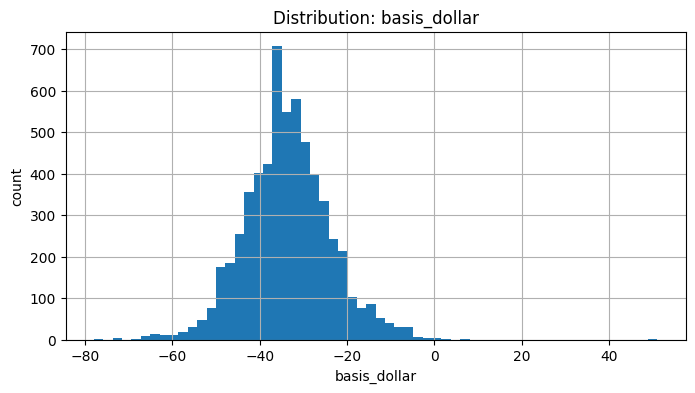

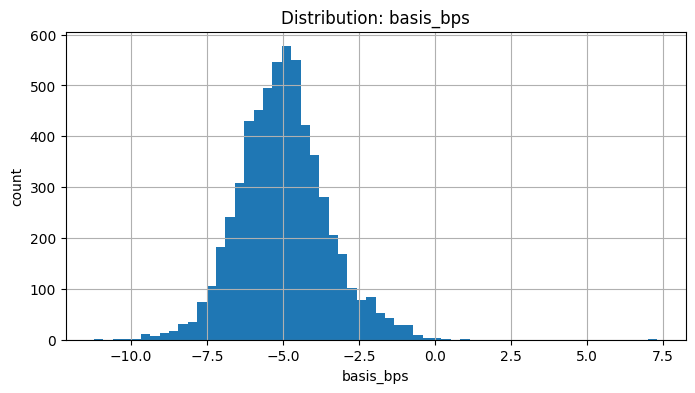

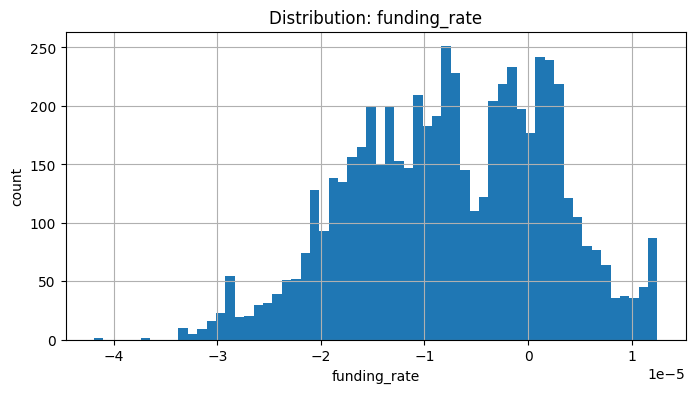

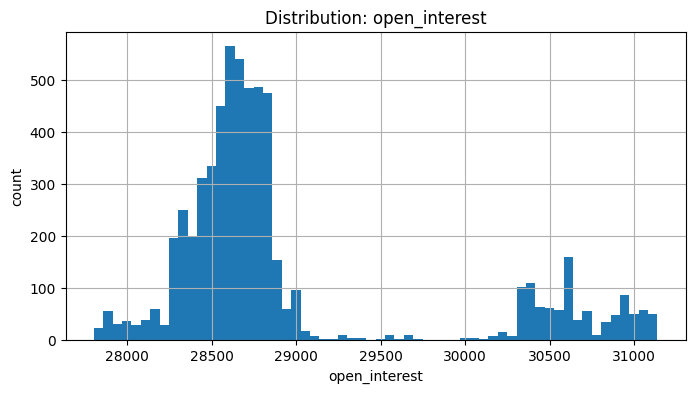

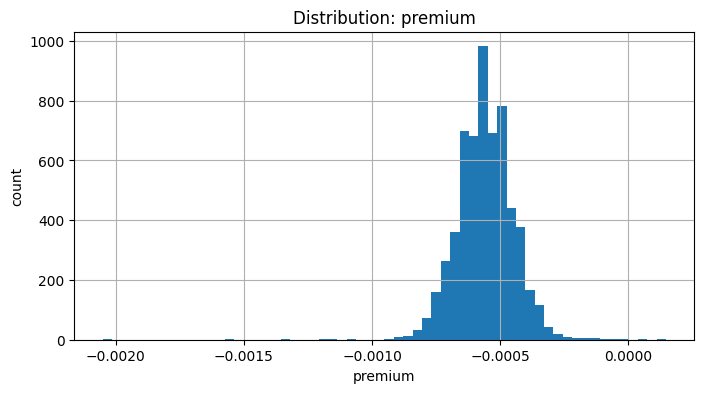

In [10]:
cols_to_plot = ["basis_dollar", "basis_bps", "funding_rate", "open_interest", "premium"]

for col in cols_to_plot:
    plt.figure(figsize=(8, 4))
    df[col].dropna().hist(bins=60)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

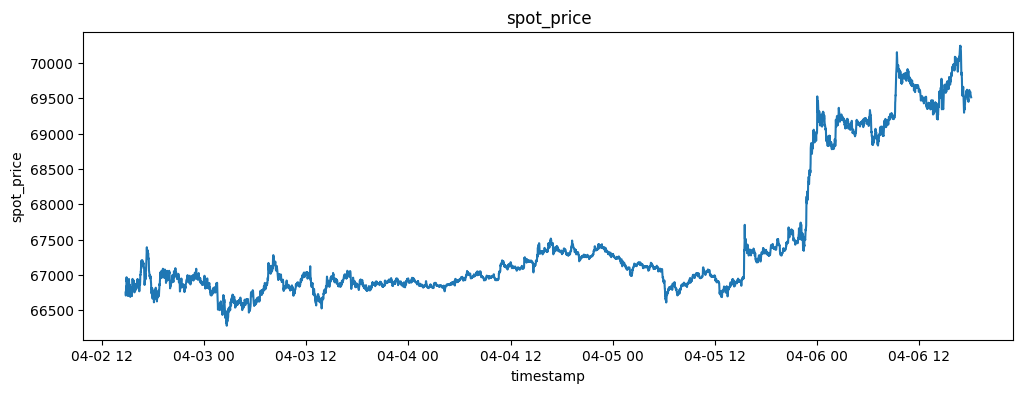

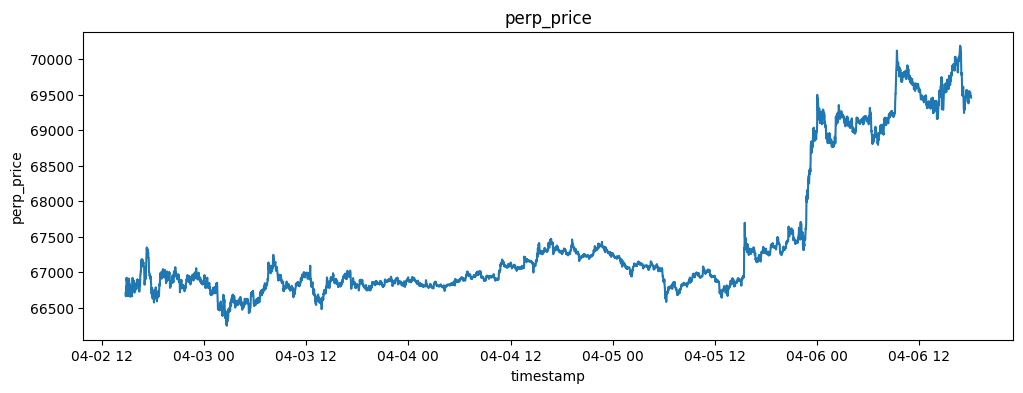

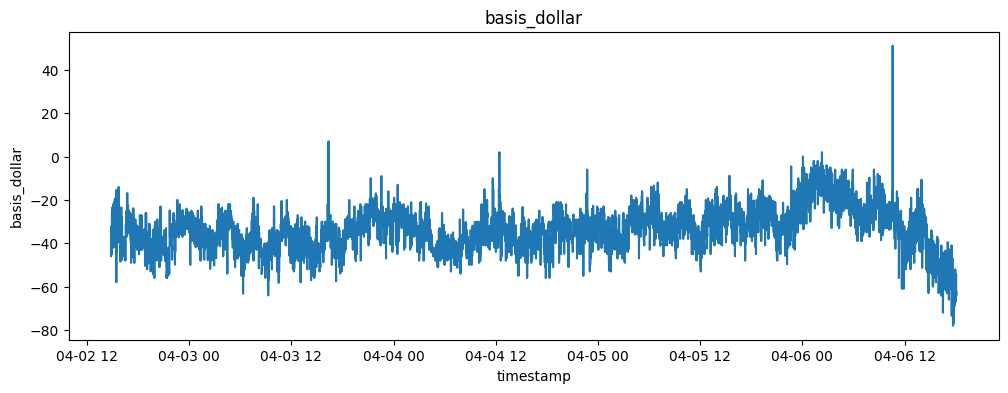

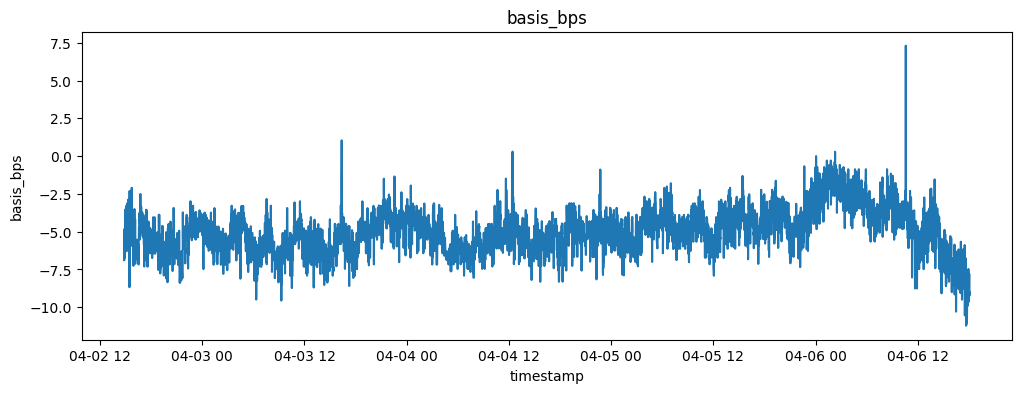

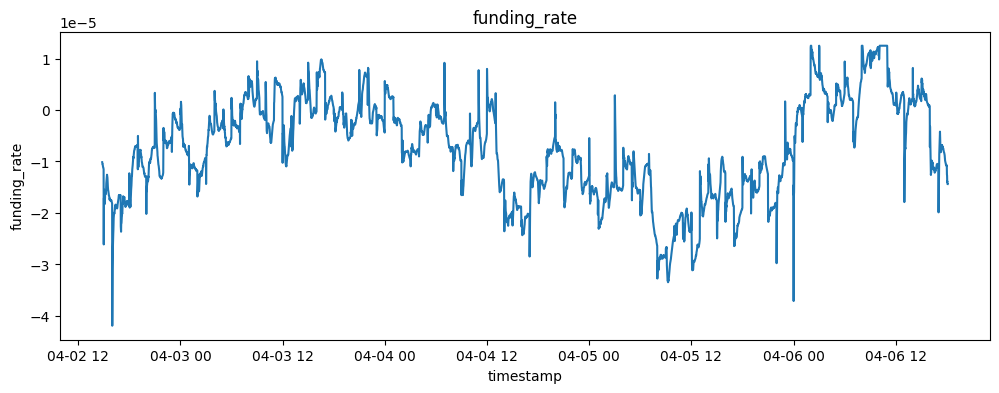

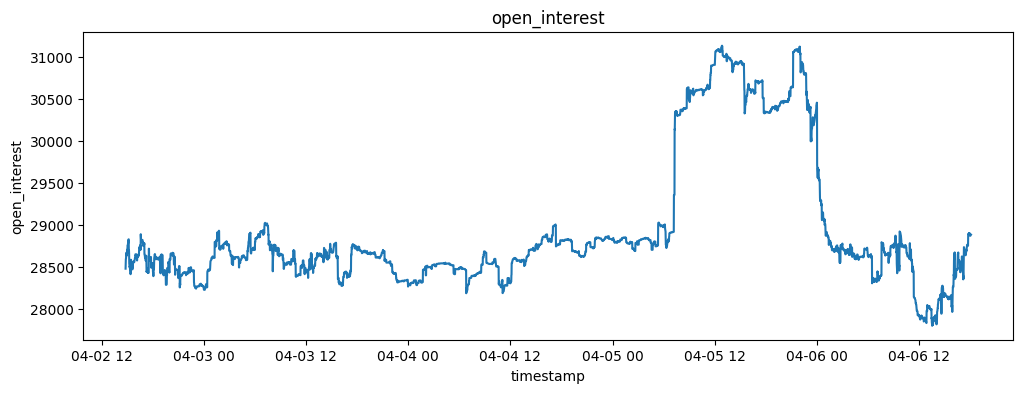

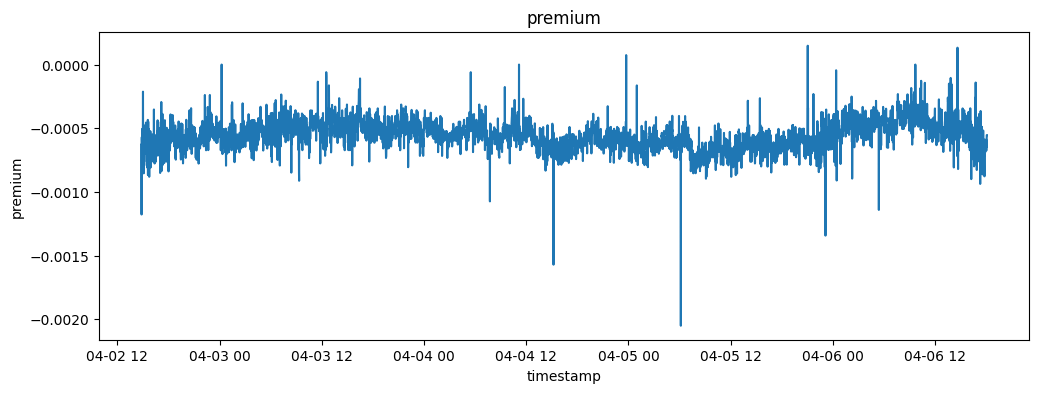

In [11]:
time_series_cols = ["spot_price", "perp_price", "basis_dollar", "basis_bps","funding_rate", "open_interest", "premium"]

for col in time_series_cols:
    plt.figure(figsize=(12, 4))
    plt.plot(df["timestamp"], df[col])
    plt.title(col)
    plt.xlabel("timestamp")
    plt.ylabel(col)
    plt.show()

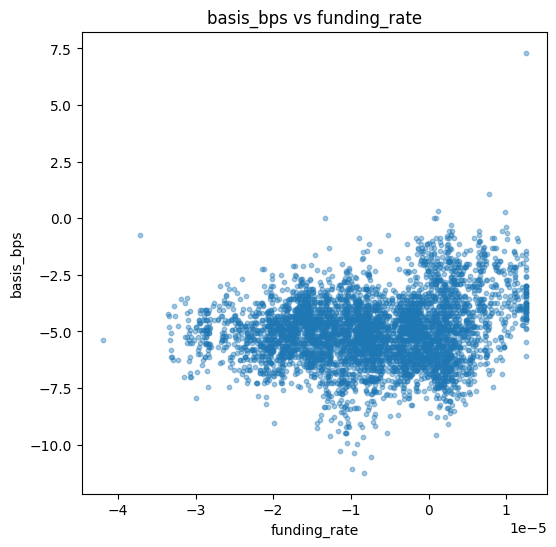

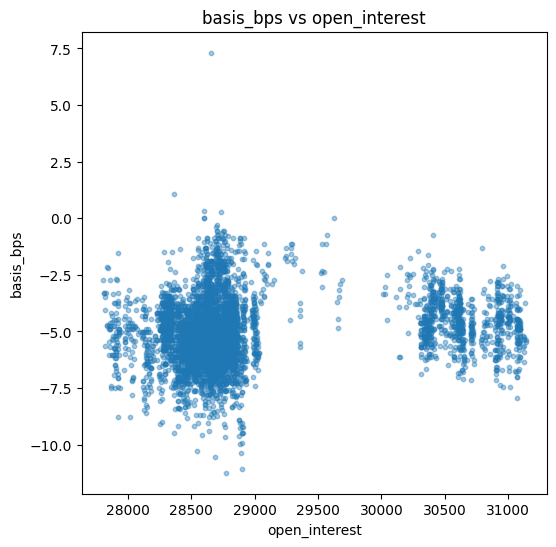

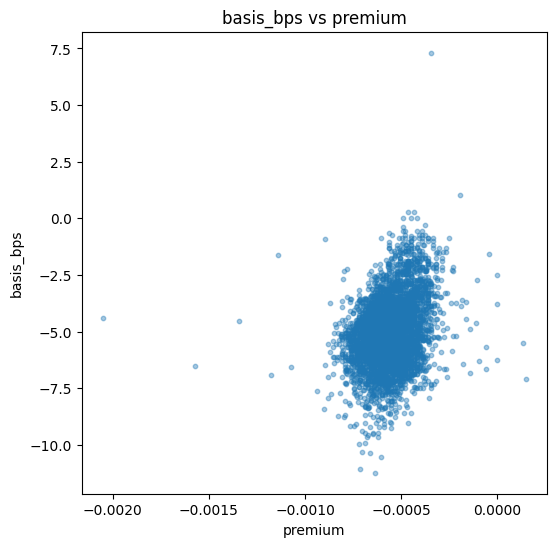

In [12]:
pairs = [
    ("funding_rate", "basis_bps"),
    ("open_interest", "basis_bps"),
    ("premium", "basis_bps"),
]

for x, y in pairs:
    if x in df.columns and y in df.columns:
        temp = df[[x, y]].dropna()
        if len(temp) > 5000:
            temp = temp.sample(5000, random_state=0)
        plt.figure(figsize=(6, 6))
        plt.scatter(temp[x], temp[y], alpha=0.4, s=10)
        plt.xlabel(x)
        plt.ylabel(y)
        plt.title(f"{y} vs {x}")
        plt.show()

In [13]:
corr_cols = [
        "basis_dollar", "basis_bps", "funding_rate", "open_interest", "premium",
        "spot_price", "perp_price", "mark_price", "oracle_price", "ctx_mid_price",
        "day_notional_volume"
]

corr = df[corr_cols].corr()

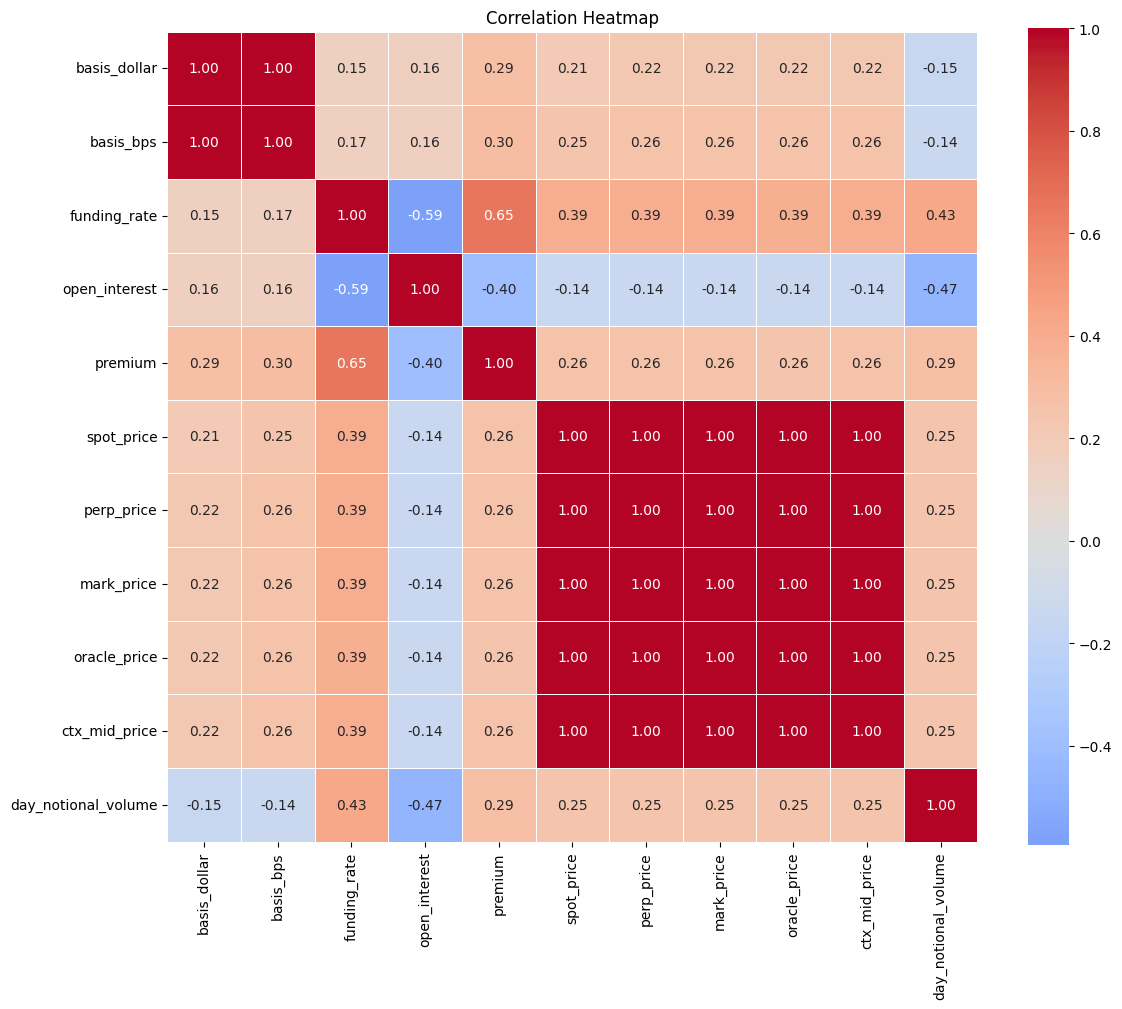

In [14]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [15]:
# safer log transform for OI
df["log_open_interest"] = np.log(df["open_interest"].replace(0, np.nan))

# returns
df["spot_ret_1m"] = np.log(df["spot_price"]).diff()

df["perp_ret_1m"] = np.log(df["perp_price"]).diff()

# OI changes
df["d_open_interest"] = df["open_interest"].diff()
df["d_log_open_interest"] = df["log_open_interest"].diff()

# basis changes
df["basis_bps_change_1m"] = df["basis_bps"].diff()

# rolling realized vol
df["spot_rv_15m"] = df["spot_ret_1m"].rolling(15).std()

# future targets
for h in [1, 5, 15, 60]:
    df[f"future_basis_change_{h}m"] = df["basis_bps"].shift(-h) - df["basis_bps"]
    df[f"future_abs_basis_change_{h}m"] = df[f"future_basis_change_{h}m"].abs()

df.head()

,timestamp,price_measurement_timestamp,ctx_recorded_at_ms,spot_price,perp_price,spot_microprice,perp_microprice,basis_dollar,basis_bps,midprice_basis,...,basis_bps_change_1m,spot_rv_15m,future_basis_change_1m,future_abs_basis_change_1m,future_basis_change_5m,future_abs_basis_change_5m,future_basis_change_15m,future_abs_basis_change_15m,future_basis_change_60m,future_abs_basis_change_60m
0,2026-04-02 14:49:00+00:00,1775141399981,1775141399359,66751.5,66707.5,66751.013923,66707.803146,-44.000000,-6.591612,-44.000000,...,NaN,NaN,-0.307172,0.307172,0.907895,0.907895,2.405937,2.405937,1.762991,1.762991
1,2026-04-02 14:50:00+00:00,1775141459895,1775141459369,66708.5,66662.5,66708.502217,66662.984935,-46.020756,-6.898784,-46.020756,...,-0.307172,NaN,1.955816,1.955816,0.179206,0.179206,1.500924,1.500924,2.034241,2.034241
2,2026-04-02 14:51:00+00:00,1775141519984,1775141519503,66761.5,66728.5,66761.802953,66728.010363,-32.999998,-4.942968,-32.999998,...,1.955816,NaN,-0.980910,0.980910,1.030720,1.030720,1.667992,1.667992,-0.995499,0.995499
3,2026-04-02 14:52:00+00:00,1775141579949,1775141579541,66836.0,66797.5,66833.326326,66797.999680,-39.592831,-5.923878,-39.592831,...,-0.980910,NaN,1.121084,1.121084,2.361556,2.361556,-0.371953,0.371953,0.605152,0.605152
4,2026-04-02 14:53:00+00:00,1775141639971,1775141639457,66818.5,66786.5,66818.775533,66786.577984,-32.091549,-4.802794,-32.091549,...,1.121084,NaN,-0.880923,0.880923,0.028820,0.028820,0.730231,0.730231,-0.437786,0.437786


In [16]:
feature_cols = [
    c for c in [
        "basis_bps", "basis_bps_change_1m",
        "funding_rate", "open_interest", "log_open_interest",
        "d_open_interest", "d_log_open_interest",
        "spot_ret_1m", "perp_ret_1m", "spot_rv_15m",
        "future_basis_change_1m", "future_basis_change_5m",
        "future_basis_change_15m", "future_basis_change_60m"
    ] if c in df.columns
]

df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
basis_bps,5955.0,-4.995062,1.458424,-11.228658,-5.968234,-5.039132,-4.157757e+00,7.309270
basis_bps_change_1m,5954.0,-0.000408,0.996706,-11.555760,-0.592131,0.000000,5.938237e-01,11.464448
funding_rate,5955.0,-0.000007,0.000009,-0.000042,-0.000014,-0.000007,2.049500e-07,0.000013
open_interest,5955.0,28944.485972,805.066251,27803.449540,28510.030630,28673.961500,2.884374e+04,31138.000000
log_open_interest,5955.0,10.272759,0.027244,10.232915,10.258011,10.263745,1.026965e+01,10.346184
d_open_interest,5954.0,0.068128,31.203953,-690.485500,-1.342225,0.076650,2.005190e+00,782.214860
d_log_open_interest,5954.0,0.000002,0.001072,-0.022972,-0.000047,0.000003,6.920130e-05,0.026292
spot_ret_1m,5954.0,0.000007,0.000411,-0.004628,-0.000150,0.000000,1.644768e-04,0.006074
perp_ret_1m,5954.0,0.000007,0.000423,-0.004645,-0.000164,0.000000,1.790965e-04,0.005917
spot_rv_15m,5940.0,0.000342,0.000226,0.000027,0.000189,0.000288,4.301186e-04,0.002030


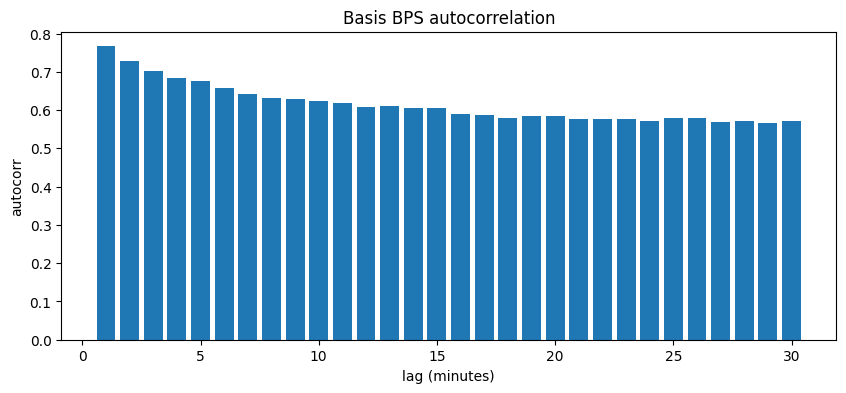

In [17]:
max_lag = 30
acf_vals = [df["basis_bps"].autocorr(lag=i) for i in range(1, max_lag + 1)]

plt.figure(figsize=(10, 4))
plt.bar(range(1, max_lag + 1), acf_vals)
plt.title("Basis BPS autocorrelation")
plt.xlabel("lag (minutes)")
plt.ylabel("autocorr")
plt.show()

In [18]:
temp = df[["basis_bps"]].dropna().copy()
temp["basis_bps_lag1"] = temp["basis_bps"].shift(1)
temp = temp.dropna()

X = sm.add_constant(temp["basis_bps_lag1"])
y = temp["basis_bps"]

ar1 = sm.OLS(y, X).fit()
phi = ar1.params["basis_bps_lag1"]

print(ar1.summary())

                            OLS Regression Results                            
Dep. Variable:              basis_bps   R-squared:                       0.587
Model:                            OLS   Adj. R-squared:                  0.587
Method:                 Least Squares   F-statistic:                     8469.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:51:37   Log-Likelihood:                -8060.0
No. Observations:                5954   AIC:                         1.612e+04
Df Residuals:                    5952   BIC:                         1.614e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.1653      0.043    -26.

In [19]:
if 0 < abs(phi) < 1:
    half_life = -np.log(2) / np.log(abs(phi))
    print("Estimated half-life (minutes):", half_life)
else:
    print("Half-life not well-defined because |phi| is not between 0 and 1.")

Estimated half-life (minutes): 2.609842598095315


In [20]:
basis_series = df["basis_bps"].dropna()

if len(basis_series) > 20:
    adf_result = adfuller(basis_series)
    print("ADF statistic:", adf_result[0])
    print("p-value:", adf_result[1])
    print("critical values:", adf_result[4])
else:
    print("Not enough data for ADF test.")

ADF statistic: -3.2326085691185744
p-value: 0.018173074297674372
critical values: {'1%': -3.4314549041141413, '5%': -2.8620282648579654, '10%': -2.567029901100001}


## Interpretation:

- Basis looks to be a stationary mean reverting process (need more data to be sure)


### Tests:

- high funding vs low funding impacts
- rising OI vs falling OI periods



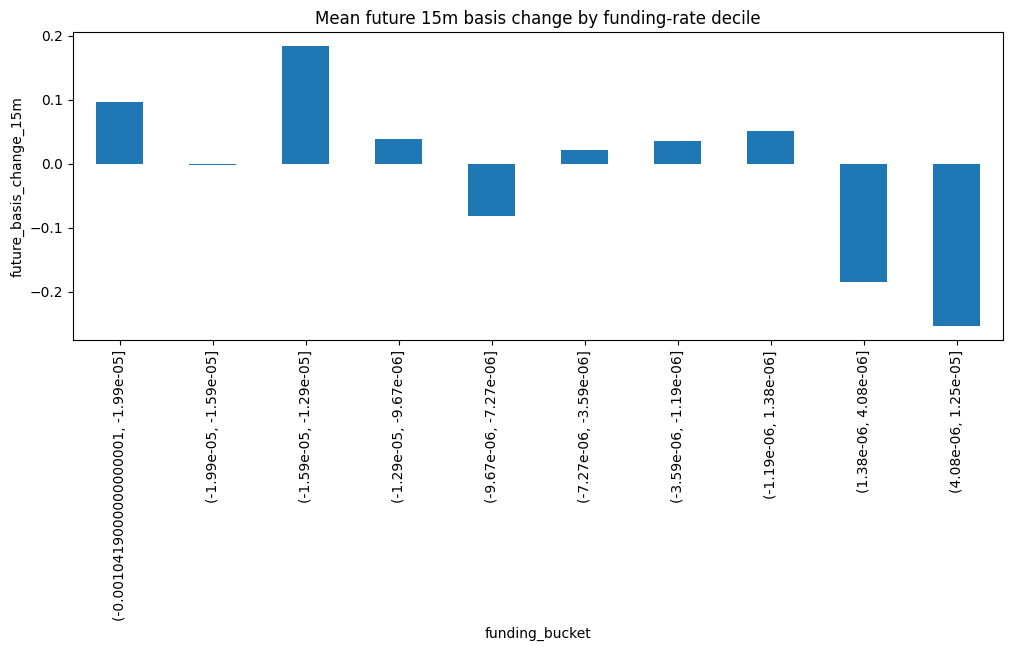

In [21]:
temp = df[["funding_rate", "future_basis_change_15m"]].dropna().copy()
temp["funding_bucket"] = pd.qcut(temp["funding_rate"], q=10, duplicates="drop")
bucketed = temp.groupby("funding_bucket", observed=False)["future_basis_change_15m"].mean()

plt.figure(figsize=(12, 4))
bucketed.plot(kind="bar")
plt.title("Mean future 15m basis change by funding-rate decile")
plt.ylabel("future_basis_change_15m")
plt.show()

In [22]:
bucketed

funding_bucket
(-0.0010419000000000001, -1.99e-05]    0.096021
(-1.99e-05, -1.59e-05]                -0.002522
(-1.59e-05, -1.29e-05]                 0.183270
(-1.29e-05, -9.67e-06]                 0.038100
(-9.67e-06, -7.27e-06]                -0.081751
(-7.27e-06, -3.59e-06]                 0.021799
(-3.59e-06, -1.19e-06]                 0.036213
(-1.19e-06, 1.38e-06]                  0.051834
(1.38e-06, 4.08e-06]                  -0.184207
(4.08e-06, 1.25e-05]                  -0.253937
Name: future_basis_change_15m, dtype: float64

## Interepretation

- Low funding tends to be followed by basis rising, and high funding tends to be followed by basis falling

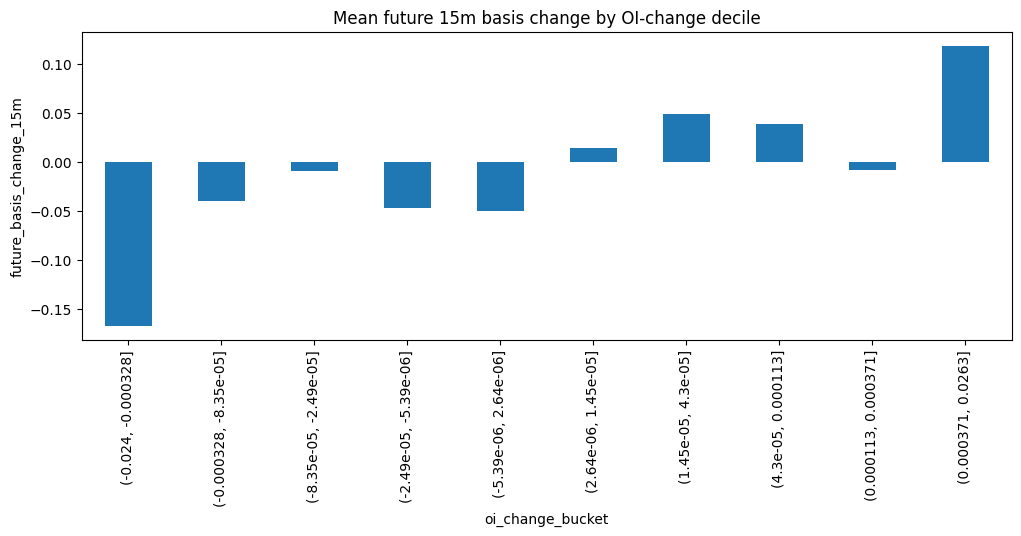

In [23]:
temp = df[["d_log_open_interest", "future_basis_change_15m"]].dropna().copy()
temp["oi_change_bucket"] = pd.qcut(temp["d_log_open_interest"], q=10, duplicates="drop")
bucketed = temp.groupby("oi_change_bucket", observed=False)["future_basis_change_15m"].mean()

plt.figure(figsize=(12, 4))
bucketed.plot(kind="bar")
plt.title("Mean future 15m basis change by OI-change decile")
plt.ylabel("future_basis_change_15m")
plt.show()

In [24]:
bucketed

oi_change_bucket
(-0.024, -0.000328]      -0.166869
(-0.000328, -8.35e-05]   -0.039687
(-8.35e-05, -2.49e-05]   -0.009094
(-2.49e-05, -5.39e-06]   -0.046690
(-5.39e-06, 2.64e-06]    -0.049915
(2.64e-06, 1.45e-05]      0.014880
(1.45e-05, 4.3e-05]       0.048812
(4.3e-05, 0.000113]       0.038604
(0.000113, 0.000371]     -0.007949
(0.000371, 0.0263]        0.118702
Name: future_basis_change_15m, dtype: float64

## Interpretation

- OI change alone does not show a strong, stable, monotonic relationship with future 15-minute basis change in this sample.

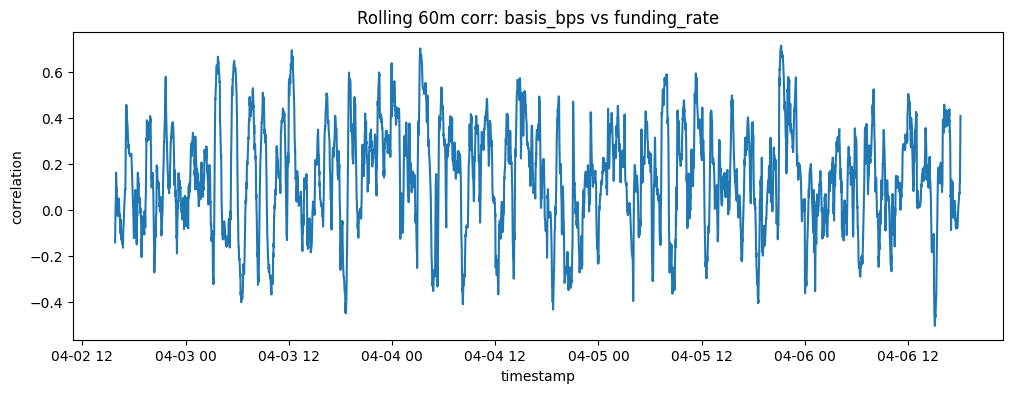

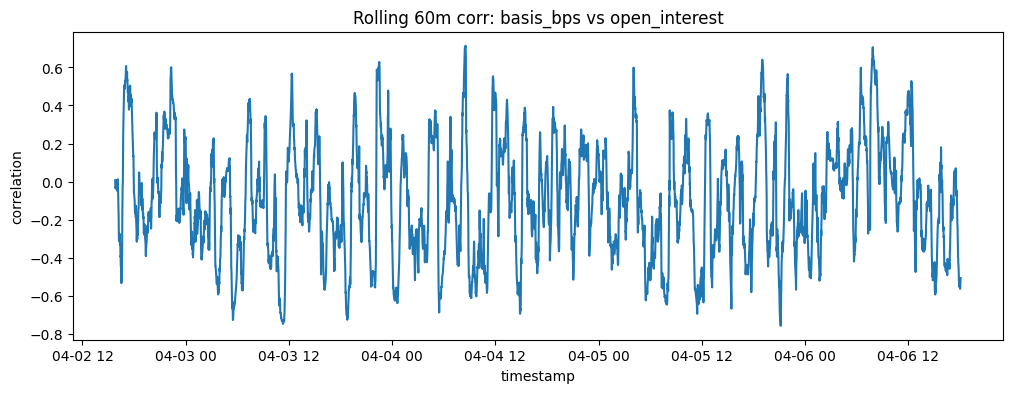

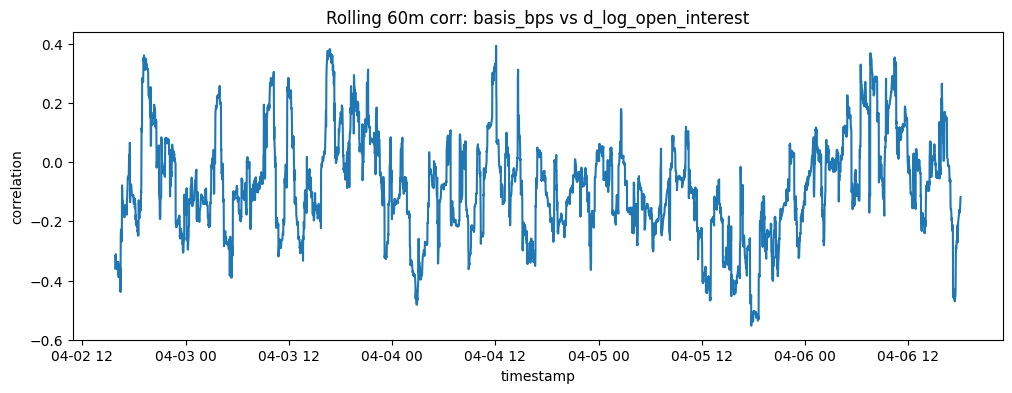

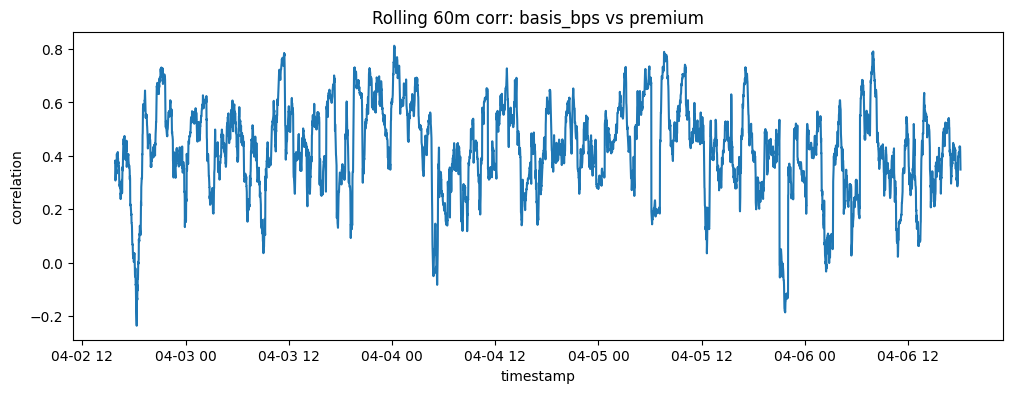

In [25]:
window = 60  # 60 minutes

for x in ["funding_rate", "open_interest", "d_log_open_interest", "premium"]:
    rolling_corr = df["basis_bps"].rolling(window).corr(df[x])

    plt.figure(figsize=(12, 4))
    plt.plot(df["timestamp"], rolling_corr)
    plt.title(f"Rolling {window}m corr: basis_bps vs {x}")
    plt.xlabel("timestamp")
    plt.ylabel("correlation")
    plt.show()

In [26]:
reg_cols = ["basis_bps", "funding_rate", "premium", "log_open_interest"]
reg_cols = [c for c in reg_cols if c in df.columns]

temp = df[reg_cols].dropna().copy()

X = temp.drop(columns=["basis_bps"])
X = sm.add_constant(X)
y = temp["basis_bps"]

model_contemp = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
print(model_contemp.summary())

                            OLS Regression Results                            
Dep. Variable:              basis_bps   R-squared:                       0.195
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     126.2
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           2.86e-79
Time:                        14:51:40   Log-Likelihood:                -10052.
No. Observations:                5955   AIC:                         2.011e+04
Df Residuals:                    5951   BIC:                         2.014e+04
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              -223.1500     12.74

In [27]:
reg_cols = [
    "future_basis_change_15m",
    "basis_bps",
    "funding_rate",
    "d_log_open_interest",
    "premium",
    "spot_ret_1m",
    "spot_rv_15m"
]
reg_cols = [c for c in reg_cols if c in df.columns]

temp = df[reg_cols].dropna().copy()

X = temp.drop(columns=["future_basis_change_15m"])
X = sm.add_constant(X)
y = temp["future_basis_change_15m"]

model_pred_15m = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 15})
print(model_pred_15m.summary())

                               OLS Regression Results                              
Dep. Variable:     future_basis_change_15m   R-squared:                       0.208
Model:                                 OLS   Adj. R-squared:                  0.207
Method:                      Least Squares   F-statistic:                     46.85
Date:                     Mon, 06 Apr 2026   Prob (F-statistic):           2.12e-56
Time:                             14:51:40   Log-Likelihood:                -9234.0
No. Observations:                     5925   AIC:                         1.848e+04
Df Residuals:                         5918   BIC:                         1.853e+04
Df Model:                                6                                         
Covariance Type:                       HAC                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------

In [28]:
results = []

for h in [1, 5, 15, 60]:
    target = f"future_basis_change_{h}m"
    reg_cols = [
        target,
        "basis_bps",
        "funding_rate",
        "d_log_open_interest",
        "premium",
        "spot_ret_1m",
        "spot_rv_15m"
    ]
    reg_cols = [c for c in reg_cols if c in df.columns]

    temp = df[reg_cols].dropna().copy()
    if len(temp) < 30:
        continue

    X = sm.add_constant(temp.drop(columns=[target]))
    y = temp[target]

    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": min(h, 20)})

    for var in X.columns:
        if var == "const":
            continue
        results.append({
            "horizon_m": h,
            "variable": var,
            "coef": model.params[var],
            "tstat": model.tvalues[var],
            "pvalue": model.pvalues[var],
            "nobs": int(model.nobs),
            "r2": model.rsquared
        })

results_df = pd.DataFrame(results)
results_df.sort_values(["variable", "horizon_m"])

,horizon_m,variable,coef,tstat,pvalue,nobs,r2
0,1,basis_bps,-0.226944,-17.787764,8.791816e-71,5939,0.123033
6,5,basis_bps,-0.304133,-17.655397,9.248039e-70,5935,0.171521
12,15,basis_bps,-0.359141,-12.619128,1.656463e-36,5925,0.207713
18,60,basis_bps,-0.461770,-11.478375,1.694341e-30,5880,0.253498
2,1,d_log_open_interest,-20.120324,-1.836832,6.623476e-02,5939,0.123033
8,5,d_log_open_interest,-13.755382,-0.922292,3.563761e-01,5935,0.171521
14,15,d_log_open_interest,14.552571,0.924777,3.550818e-01,5925,0.207713
20,60,d_log_open_interest,8.467943,0.519139,6.036637e-01,5880,0.253498
1,1,funding_rate,10051.098849,6.084964,1.165172e-09,5939,0.123033
7,5,funding_rate,14334.400573,5.380811,7.415109e-08,5935,0.171521


## Interpretations

- Basis is strongly mean-reverting
- The mean-reversion effect gets stronger as the horizon increases from 1m to 60m
- Premium contains predictive information about future basis compression, especially at short horizons (premium is essentially a derivative of basis so this is to be expected)

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor  
df_reg = df.sort_values("timestamp").copy() if "timestamp" in df.columns else df.copy()

ewma_span = 60
df_reg["eq_basis_proxy_bps"] = df_reg["basis_bps"].ewm(span=ewma_span, adjust=False).mean()

feature_cols = [
    "funding_rate",
    "d_log_open_interest",
    "spot_ret_1m",
    "spot_rv_15m",
]

feature_cols = [c for c in feature_cols if c in df_reg.columns]

target = "eq_basis_proxy_bps"
use_cols = [target] + feature_cols
temp = df_reg[use_cols].dropna().copy()


X_raw = sm.add_constant(temp[feature_cols])
y = temp[target]

model_eq_basis_raw = sm.OLS(y, X_raw).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 15}
)

print("\n=== Current equilibrium-basis proxy regression (raw units) ===\n")
print(model_eq_basis_raw.summary())

temp["theta_hat_bps"] = model_eq_basis_raw.predict(X_raw)


temp["theta_hat_log_basis"] = np.log(
    np.clip(1.0 + temp["theta_hat_bps"] / 10000.0, 1e-8, None)
)

print("\nSample of fitted targets:\n")
print(temp[[target, "theta_hat_bps", "theta_hat_log_basis"]].head())


X_std = temp[feature_cols].copy()
for c in X_std.columns:
    std = X_std[c].std()
    if std == 0 or np.isnan(std):
        raise ValueError(f"Column {c} has zero or invalid std.")
    X_std[c] = (X_std[c] - X_std[c].mean()) / std

X_std = sm.add_constant(X_std)

model_eq_basis_std = sm.OLS(y, X_std).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 15}
)

print("\n=== Standardized version (for comparing covariate influence) ===\n")
print(model_eq_basis_std.summary())

# -----------------------------
# 7) VIF check
# -----------------------------
vif_df = pd.DataFrame({
    "variable": X_std.columns,
    "VIF": [variance_inflation_factor(X_std.values, i) for i in range(X_std.shape[1])]
})
print("\n=== VIFs ===\n")
print(vif_df)

# -----------------------------
# 8) attach target back to main df if desired
# -----------------------------
df_reg.loc[temp.index, "theta_hat_bps"] = temp["theta_hat_bps"]
df_reg.loc[temp.index, "theta_hat_log_basis"] = temp["theta_hat_log_basis"]


=== Current equilibrium-basis proxy regression (raw units) ===

                            OLS Regression Results                            
Dep. Variable:     eq_basis_proxy_bps   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     5.377
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           0.000255
Time:                        15:04:12   Log-Likelihood:                -8798.2
No. Observations:                5940   AIC:                         1.761e+04
Df Residuals:                    5935   BIC:                         1.764e+04
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------